In [19]:
!rm -rf clone && git clone https://github.com/pui-sum-rv/lab1 clone && cp -a clone/. .

Cloning into 'clone'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 110 (delta 34), reused 80 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 6.53 MiB | 27.84 MiB/s, done.
Resolving deltas: 100% (34/34), done.


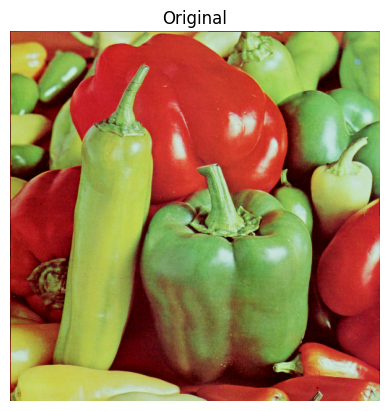

In [20]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread("images/pepper.bmp")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")
plt.show()

In [21]:
# Task 1 Image Manipulation

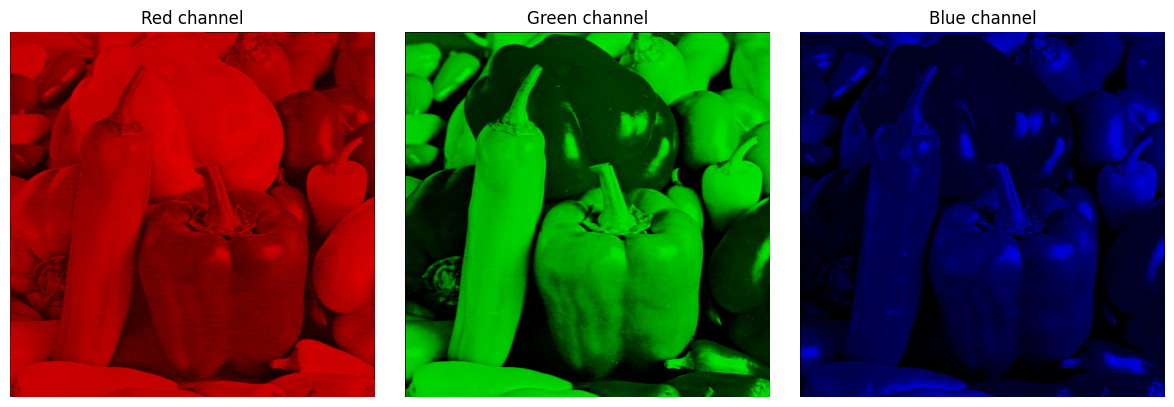

In [22]:
# OpenCV učitava kao BGR
B, G, R = cv2.split(img)

# pravimo prazne kanale
zeros = np.zeros_like(B)

# svaki kanal posebno
R_img = cv2.merge([zeros, zeros, R])
G_img = cv2.merge([zeros, G, zeros])
B_img = cv2.merge([B, zeros, zeros])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(R_img, cv2.COLOR_BGR2RGB))
plt.title("Red channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(G_img, cv2.COLOR_BGR2RGB))
plt.title("Green channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(B_img, cv2.COLOR_BGR2RGB))
plt.title("Blue channel")
plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
# Task 2 Image Manipulation

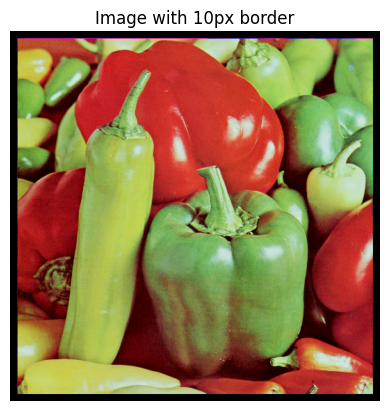

In [24]:
# Dodavanje granice od 10 piksela oko slike
# BORDER_CONSTANT -> rubovi su ispunjeni konstantnom bojom (crna)
bordered = cv2.copyMakeBorder(
    img,
    top=10, bottom=10,
    left=10, right=10,
    borderType=cv2.BORDER_CONSTANT,
    value=[0, 0, 0]  # crna boja (BGR)
)

# Prikaz (pretvaramo u RGB za matplotlib)
plt.imshow(cv2.cvtColor(bordered, cv2.COLOR_BGR2RGB))
plt.title("Image with 10px border")
plt.axis("off")
plt.show()

In [25]:
# Task 3 Image Manipulation

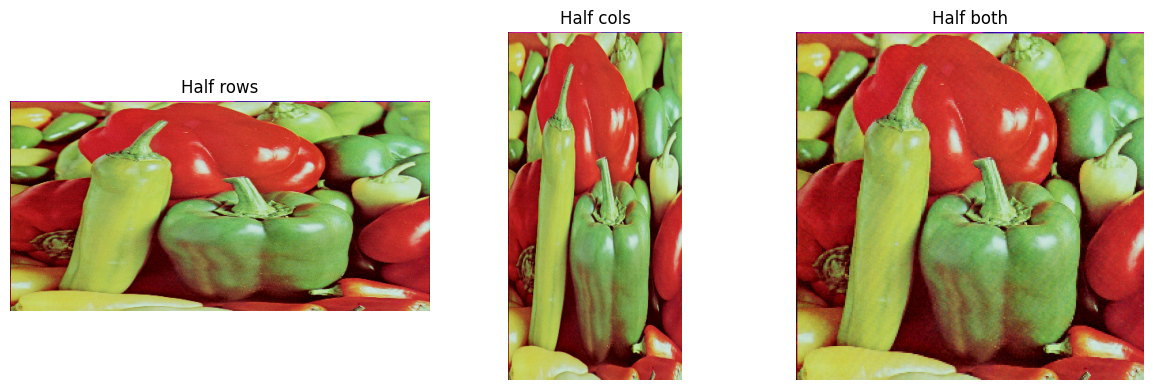

In [26]:
# Uzimamo svaki drugi red (polovina visine)
half_rows = img[::2, :, :]

# Uzimamo svaki drugi stupac (polovina širine)
half_cols = img[:, ::2, :]

# Uzimamo svaki drugi red i stupac (1/4 slike)
half_both = img[::2, ::2, :]

# Prikaz rezultata
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(half_rows, cv2.COLOR_BGR2RGB))
plt.title("Half rows")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(half_cols, cv2.COLOR_BGR2RGB))
plt.title("Half cols")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(half_both, cv2.COLOR_BGR2RGB))
plt.title("Half both")
plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
# Task 1 Color spaces

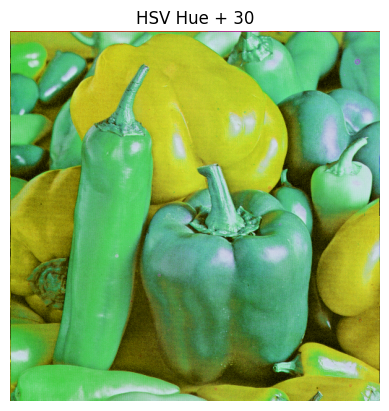

In [28]:
# Konverzija iz BGR u HSV color space
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Razdvajanje HSV slike na 3 odvojena kanala> boja, intenzitet, svjetlina
h, s, v = cv2.split(hsv)

# dodajemo +30 na Hue (boju). mora se koristiti modulo 180 jer OpenCV Hue ide od 0 do 179

h = (h.astype(int) + 30) % 180
h = h.astype(np.uint8)

# spajanje izmijenjenih kanala nazad u HSV sliku
hsv_shifted = cv2.merge([h, s, v])

# konverzija iz HSV u RGB (za prikaz u matplotlib-u)
result = cv2.cvtColor(hsv_shifted, cv2.COLOR_HSV2RGB)

# prikaz rezultata
plt.imshow(result)
plt.title("HSV Hue + 30")
plt.axis("off")
plt.show()

In [29]:
# Task 2 Color spaces

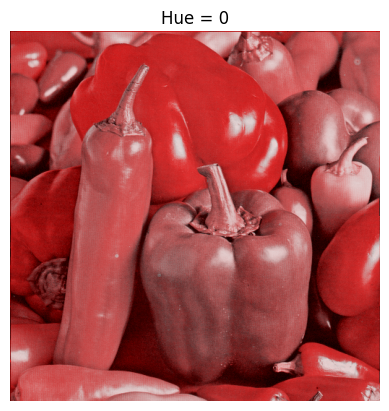

In [30]:
# Konverzija iz BGR u HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Razdvajanje kanala
h, s, v = cv2.split(hsv)

# Postavljanje Hue kanala na 0
h[:] = 0

# Spajanje nazad
hsv_new = cv2.merge([h, s, v])

# Konverzija u RGB za prikaz
result = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2RGB)

# Prikaz
plt.imshow(result)
plt.title("Hue = 0")
plt.axis("off")
plt.show()